# Tutorial: SECTOR on sequencing-based spatial transcriptomics data

This notebook demonstrates how to run **SECTOR** on representative sequencing-based spatial transcriptomics (ST) datasets used in the manuscript:

1. **10x Visium DLPFC** (slice `151673`)
2. **Stereo-seq mouse embryo** (slice `E9.5_E1S1`)

The same workflow can be adapted to custom sequencing-based ST datasets: prepare an `.h5ad` file, specify the dataset path and key parameters, train SECTOR, infer spatial domains and pseudotime, and optionally evaluate the results when annotations are available.

Guidance on adapting this notebook to custom sequencing-based ST datasets and diagnosing common failure modes is provided at the end of the notebook.


## Example 1: 10x Visium DLPFC (slice `151673`)

This example uses a standard 10x Visium dorsolateral prefrontal cortex (DLPFC) benchmark slice with manual cortical-layer annotations. SECTOR is run in evaluation mode so that NMI, HOM and COM can be reported after prediction. These annotations are used only for evaluation and are not used during model training.


### 1. Load the SECTOR package


In [1]:
from sector import SECTOR

### 2. Check the expected input format


SECTOR takes an `.h5ad` file that can be loaded as an `AnnData` object. For a custom dataset, the object should contain:

- `adata.X`: expression matrix, preferably raw counts or count-like values; dense and sparse matrices are both supported.
- `adata.obsm["spatial"]`: two-dimensional spatial coordinates with shape `n_obs × 2`.
- Optional `adata.obs[label_key]`: ground-truth annotation used only for evaluation when `eval_mode=1`.

Below, we inspect the DLPFC input object used in this tutorial.


In [2]:
import scanpy as sc

input_adata = sc.read_h5ad('./data/10x_visium/151673.h5ad')
input_adata

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

`adata.X` should contain the expression matrix. During training, SECTOR performs its own preprocessing, including low-expression gene filtering (`min_cells=5` by default), total-count normalisation (`target_sum=1e4` by default), HVG selection (`n_top_genes=2000` by default), and PCA (`n_comps=20` by default).


In [3]:
input_adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 8021506 stored elements and shape (3639, 33538)>

The input object should also contain spatial coordinates in `adata.obsm["spatial"]`. These coordinates are used to construct the spatial neighbourhood graph.


In [4]:
input_adata.obsm['spatial']

array([[ 9791,  8468],
       [ 5769,  2807],
       [ 4068,  9505],
       ...,
       [ 4631,  7831],
       [ 5571, 11193],
       [ 6317,  3291]], shape=(3639, 2))

If annotations are available, they can be stored in `adata.obs`. In this DLPFC example, the annotation column is `Region`. SECTOR is label-free: this column is used only when `eval_mode=1` to compute evaluation metrics.


In [5]:
input_adata.obs['Region']

AAACAAGTATCTCCCA-1    Layer3
AAACAATCTACTAGCA-1    Layer1
AAACACCAATAACTGC-1        WM
AAACAGAGCGACTCCT-1    Layer3
AAACAGCTTTCAGAAG-1    Layer5
                       ...  
TTGTTTCACATCCAGG-1        WM
TTGTTTCATTAGTCTA-1        WM
TTGTTTCCATACAACT-1    Layer6
TTGTTTGTATTACACG-1        WM
TTGTTTGTGTAAATTC-1    Layer2
Name: Region, Length: 3639, dtype: category
Categories (7, object): ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']

### 3. Initialise a SECTOR model


SECTOR loads data using the path convention:

```text
dataset_path / dataset / slice.h5ad
```

This structure is convenient when a project contains multiple datasets or multiple slices per dataset.

Key dataset and evaluation parameters:

- `dataset_path`: root directory containing the ST datasets.
- `dataset`: dataset folder name.
- `slice`: file name without the `.h5ad` suffix.
- `num_clusters`: expected number of spatial domains.
- `eval_mode`: set to `1` when annotations are available and evaluation metrics should be reported; set to `0` for unannotated custom datasets.
- `label`: annotation column in `adata.obs`, required only when `eval_mode=1`.

Key graph and feature parameters:

- `n_top_genes`: number of HVGs used for feature construction ($N_{HVG}$ in the manuscript), default `2000`. This is especially important for large-panel or whole-transcriptome datasets.
- `n_comps`: number of PCA components used as input features ($d$ in the manuscript), default `20`.
- `k`: number of neighbours for feature-graph construction ($k_{feat}$ in the manuscript), default `1`.
- `k_s`: number of neighbours for spatial-graph construction, default `6`.


In [6]:
m = SECTOR(
    # input slice path
    dataset_path='./data',       # Root directory for ST datasets.
    dataset='10x_visium',        # Dataset folder name.
    slice='151673',              # DLPFC slice file name without the .h5ad suffix.

    # evaluation and output
    num_clusters=7,              # Expected number of spatial domains.
    eval_mode=1,                 # Evaluation mode; annotations are used only for metric calculation.
    label='Region',              # Ground-truth annotation column in adata.obs, required when eval_mode=1.

    # key graph and feature parameters
    n_comps=20,                  # Number of PCA components.
    n_top_genes=2000,            # Number of HVGs.
    k=1,                         # Feature-graph neighbours (k_feat in the manuscript).
    k_s=6,                       # Spatial-graph neighbours.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=small/dense)
Dataset Name: 10x_visium
Number of nodes: 3611
Number of edges: 12889
Number of features: 20
Number of classes: 7 (labels loaded: True)
Feature: torch.Size([3611, 20])
edge_index: torch.Size([2, 25779])


### 4. Train the SECTOR model

Important training parameters:

- `lambda_tv`: spatial total-variation (TV) coefficient. Larger values enforce stronger spatial smoothness; smaller values preserve sharper local boundaries. We recommend `lambda_tv=2.0` as a starting point for 10x Visium datasets. Practical tuning rule: increase `lambda_tv` if domains are fragmented; decrease it if boundaries are oversmoothed.
- `lr`: learning rate for Adam optimisation, default `0.001`.
- `stability_nmi_thr`: label-free early-stopping threshold based on assignment stability between epochs. We recommend `stability_nmi_thr=0.97` for standard 10x Visium datasets.
- `balance_probe_epochs`: number of initial probe epochs used to detect severe under-use of clusters, default `20`.
- `gamma_balance`: balance-regularisation weight, activated only if the balance probe detects cluster under-use. For sequencing-based ST data, `gamma_balance=1.0` is a useful starting point.


In [7]:
m.fit(
    lambda_tv=2.0,              # Spatial TV regularisation coefficient.
    lr=0.001,                   # Learning rate.
    stability_nmi_thr=0.97,     # Label-free early-stopping threshold based on assignment stability.
    balance_probe_epochs=20,    # Number of balance-probe epochs.
    gamma_balance=1.0,          # Balance regularisation weight, used only if the probe detects cluster under-use.
)


[Probe] Starting 20 epochs with balance OFF...
[Probe] Epoch 0 | Loss=9.448453 | UsedK=6/7
[Probe] Epoch 19 | Loss=9.199598 | UsedK=5/7
[Restart] Not stably at K by end of probe (stable_hits=0/2). Restarting with gamma_balance=1.0.
Epoch: 0 [0.036s], Loss: 9.504453, NMI: 0.442709, HOM: 0.373524, COM: 0.543349, K: 6/7, 
Epoch: 1 [0.035s], Loss: 9.486593, NMI: 0.443874, HOM: 0.385537, COM: 0.523013, K: 6/7, 
Epoch: 2 [0.036s], Loss: 9.470894, NMI: 0.442144, HOM: 0.393906, COM: 0.503847, K: 6/7, 
Epoch: 3 [0.035s], Loss: 9.453794, NMI: 0.436132, HOM: 0.397516, COM: 0.483059, K: 6/7, 
Epoch: 4 [0.036s], Loss: 9.440426, NMI: 0.442634, HOM: 0.408586, COM: 0.482874, K: 6/7, 
Epoch: 5 [0.034s], Loss: 9.428242, NMI: 0.442562, HOM: 0.412525, COM: 0.477318, K: 6/7, 
Epoch: 6 [0.034s], Loss: 9.417425, NMI: 0.448375, HOM: 0.419753, COM: 0.481185, K: 6/7, 
Epoch: 7 [0.035s], Loss: 9.406250, NMI: 0.457502, HOM: 0.428740, COM: 0.490402, K: 6/7, 
Epoch: 8 [0.034s], Loss: 9.397006, NMI: 0.462163, HOM: 0

### 5. Infer and visualise spatial domains and pseudotime

Prediction-related parameters:

- `spatial_anchor`: orients the inferred pseudotime using a broad spatial direction, such as `"south"`, `"north"`, `"east"` or `"west"`.
- `root_cluster`: alternatively, users can manually orient pseudotime by specifying a predicted cluster as the starting point after inspecting the spatial domains.
- `plot`: if `True`, spatial-domain and pseudotime plots are generated and saved.
- `island_min_frac` and `island_min_abs`: optional post hoc island-cleaning parameters that reduce small disconnected fragments. For DLPFC, modest island cleaning (`island_min_frac=0.1` and `island_min_abs=40`) can improve spatial continuity.

For custom datasets, inspect the predicted domains first, then adjust `spatial_anchor`, `root_cluster` and island-cleaning settings if needed.


[Post hoc] Island cleaner changed 55 spots (min_abs=40, min_frac=0.1, max_iter=2)
[Final metrics] NMI=0.712603, HOM=0.732775, COM=0.693512, (K=7/7)


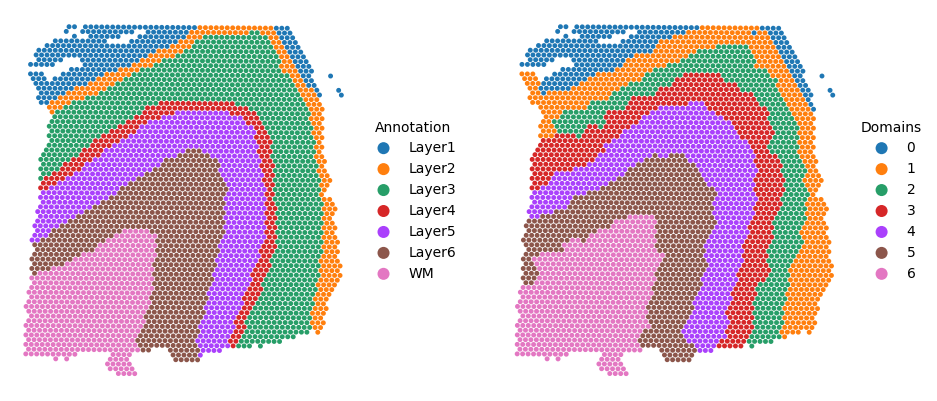

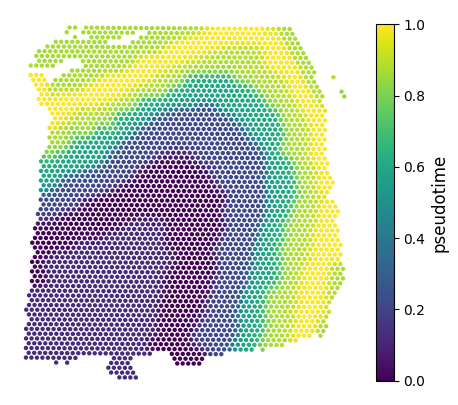

In [8]:
adata = m.pred(
    spatial_anchor='south',     # Pseudotime orientation; root_cluster can be used instead after inspecting domains.
    plot=True,                  # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.1,        # Relative minimum component size for post hoc island cleaning.
    island_min_abs=40,          # Absolute minimum component size for post hoc island cleaning.
)


### 6. Inspect evaluation metrics


When `eval_mode=1`, final clustering metrics are stored in `adata.uns["SECTOR"]["final_metrics"]`. These include NMI, HOM and COM, which are the main clustering metrics reported in the manuscript.


In [9]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.7126033695712675
HOM: 0.7327754209604006
COM: 0.6935121682339342


## Example 2: Stereo-seq mouse embryo (slice `E9.5_E1S1`)

This example uses a representative Stereo-seq mouse embryo slice from the sequencing-based benchmark group. Compared with the DLPFC Visium slice, this dataset contains more spatial locations, transcriptome-scale gene coverage and a more complex embryonic annotation set. The tutorial therefore uses a larger HVG set, more PCA components and a larger feature-graph neighbourhood.


The parameter choices below follow the settings used in the manuscript benchmark. In particular, we use `k=3`, `n_top_genes=4000` and `n_comps=50` for this Stereo-seq embryo slice.


In [10]:
m = SECTOR(
    dataset_path='./data',                      # Root directory for ST datasets.
    dataset='stereoseq',                        # Stereo-seq mouse embryo dataset.
    slice='E9.5_E1S1.MOSTA_20250830200734',     # Stereo-seq slice file name without the .h5ad suffix.
    label='Region',
    num_clusters=12,
    eval_mode=1,
    k=3,                         # Feature-graph neighbours (k_feat in the manuscript).
    n_top_genes=4000,
    n_comps=50,
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=4000, mode=small/dense)
Dataset Name: stereoseq
Number of nodes: 5913
Number of edges: 23760
Number of features: 50
Number of classes: 12 (labels loaded: True)
Feature: torch.Size([5913, 50])
edge_index: torch.Size([2, 47521])


For training, we use stronger spatial regularisation (`lambda_tv=3.0`) and a slightly lower assignment-stability threshold (`stability_nmi_thr=0.95`). The balance coefficient is kept at `gamma_balance=1.0`, a useful starting point for sequencing-based ST datasets.


In [11]:
m.fit(
    lambda_tv=3.0,              # Spatial TV regularisation coefficient.
    stability_nmi_thr=0.95,     # Label-free early-stopping threshold based on assignment stability.
    gamma_balance=1.0,          # Default balance regularisation weight for sequencing-based ST.
)


[Probe] Starting 20 epochs with balance OFF...
[Probe] Epoch 0 | Loss=10.578036 | UsedK=12/12
[Probe] Epoch 19 | Loss=10.155750 | UsedK=11/12
[Restart] Not stably at K by end of probe (stable_hits=0/2). Restarting with gamma_balance=1.0.
Epoch: 0 [0.041s], Loss: 10.690078, NMI: 0.258071, HOM: 0.220062, COM: 0.311952, K: 12/12, 
Epoch: 1 [0.042s], Loss: 10.661084, NMI: 0.275290, HOM: 0.240959, COM: 0.321029, K: 12/12, 
Epoch: 2 [0.040s], Loss: 10.631053, NMI: 0.284380, HOM: 0.253531, COM: 0.323775, K: 12/12, 
Epoch: 3 [0.040s], Loss: 10.603181, NMI: 0.289803, HOM: 0.263901, COM: 0.321345, K: 12/12, 
Epoch: 4 [0.041s], Loss: 10.574373, NMI: 0.294294, HOM: 0.271989, COM: 0.320585, K: 12/12, 
Epoch: 5 [0.039s], Loss: 10.546566, NMI: 0.295185, HOM: 0.277026, COM: 0.315892, K: 12/12, 
Epoch: 6 [0.040s], Loss: 10.523942, NMI: 0.293761, HOM: 0.279222, COM: 0.309897, K: 12/12, 
Epoch: 7 [0.040s], Loss: 10.497806, NMI: 0.295312, HOM: 0.283784, COM: 0.307817, K: 12/12, 
Epoch: 8 [0.058s], Loss: 1

For this representative Stereo-seq slice, post hoc island cleaning is turned off to avoid removing small but biologically meaningful embryonic structures. We set `spatial_anchor="north"` to orient the inferred pseudotime consistently with the broad tissue organisation; users can alternatively set `root_cluster` after inspecting the predicted domains.


[Final metrics] NMI=0.581886, HOM=0.614043, COM=0.552928, (K=12/12)


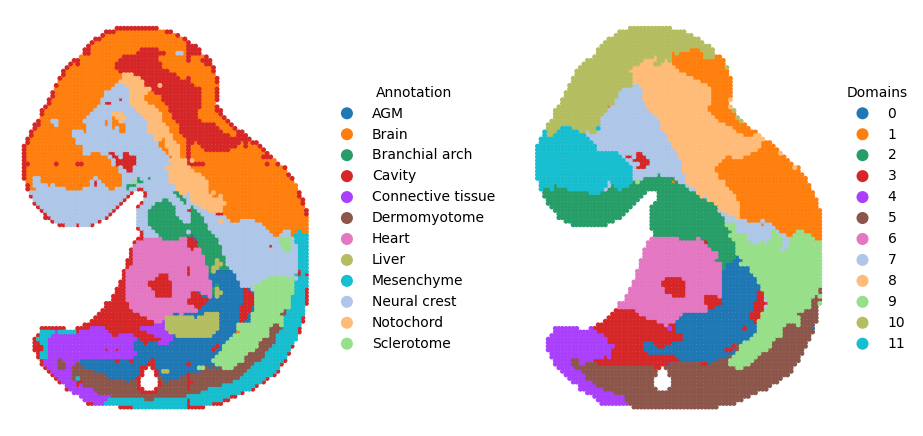

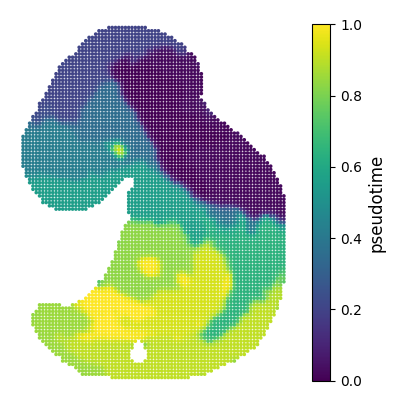

In [12]:
adata = m.pred(
    spatial_anchor='north',     # Pseudotime orientation; root_cluster can be used instead after inspecting domains.
    plot=True,                  # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.0,        # Island cleaning is turned off for this Stereo-seq example.
    island_min_abs=0,
)


The resulting evaluation metrics are shown below.


In [13]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.5818855181394882
HOM: 0.6140433534513026
COM: 0.5529283156643949


## Adapting this notebook to a custom sequencing-based ST dataset

For a new dataset, use the following checklist:

1. Save the data as an `.h5ad` file under `dataset_path / dataset / slice.h5ad`.
2. Ensure that `adata.X` contains the expression matrix and `adata.obsm["spatial"]` contains two-dimensional spatial coordinates.
3. If ground-truth annotations are available, store them in `adata.obs` and set `eval_mode=1` with the corresponding `label`; otherwise set `eval_mode=0`.
4. Set `num_clusters` to the expected number of spatial domains. If this is unknown, try a small range of plausible values and inspect both spatial maps and biological markers.
5. Tune the main dataset-dependent parameters:
   - `lambda_tv`: increase if domains are fragmented or noisy; decrease if boundaries are oversmoothed.
   - `k_s`: controls the spatial graph. Larger values enforce broader spatial neighbourhoods; smaller values preserve local boundaries.
   - `k`: controls the feature graph. Increasing it can connect similar spots/cells, but overly large values may over-aggregate heterogeneous regions.
   - `n_top_genes`: number of HVGs. For large-panel or whole-transcriptome datasets, tune this value as in the manuscript sensitivity analysis.
   - `n_comps`: PCA dimension. Moderate values are usually stable, but larger or more heterogeneous panels may benefit from additional components.
6. Keep the balance probe enabled. If clusters are severely under-used, start from `gamma_balance=1.0` for sequencing-based datasets and adjust only if necessary. If domains become unnaturally equal-sized, reduce the balance weight or reconsider `num_clusters`.
7. Use post hoc island cleaning cautiously. It can remove isolated noisy components, but overly aggressive cleaning may remove small biologically meaningful structures.
8. Use `spatial_anchor` for a broad directional pseudotime orientation, or use `root_cluster` after inspecting the predicted spatial domains.


## Diagnostics on common failure modes

SECTOR is generally robust across moderate parameter ranges, but different tissues and spatial technologies may require limited tuning. Use the patterns below to diagnose common issues and choose targeted adjustments.

### 1. Oversmoothed domains

**Typical pattern:** neighbouring anatomical regions are merged, narrow boundaries disappear, or small biologically meaningful domains are absorbed into larger regions.

Possible adjustments:

- Decrease `lambda_tv` to reduce spatial smoothing.
- Reduce spatial or feature-graph connectivity by decreasing `k_s` and/or `k`.
- Reduce post hoc island-cleaning strength by decreasing `island_min_frac` and/or `island_min_abs`.

### 2. Fragmented or noisy domains

**Typical pattern:** predicted domains contain many isolated islands, boundaries are noisy, or spatially coherent tissue regions are split into many small pieces.

Possible adjustments:

- Increase `lambda_tv` to encourage spatial coherence.
- Increase spatial or feature-graph connectivity by increasing `k_s` and/or `k`.
- Apply modest island cleaning by slightly increasing `island_min_frac` and/or `island_min_abs`.

### 3. Under-used clusters

**Typical pattern:** the number of occupied predicted clusters is smaller than `num_clusters`, or one or more clusters contain very few spots/cells.

Possible adjustments:

- Keep the balance probe enabled so SECTOR first tests whether all clusters are naturally used with `gamma_balance=0`.
- Increase `gamma_balance` only if cluster under-use persists after the balance probe.
- Reconsider whether `num_clusters` is biologically reasonable; persistent under-use can indicate that the requested number of domains is larger than the tissue structure supports.
- For large or highly heterogeneous datasets, also tune `lr`, because unstable optimisation can contribute to poor cluster usage.

### 4. Unstable training or poor convergence

**Typical pattern:** results vary substantially across runs or slices, cluster usage changes abruptly, or training does not stabilise.

Possible adjustments:

- Reduce `lr` if optimisation appears unstable, especially for large or highly heterogeneous datasets.
- Increase `epochs` if the model has not converged.
- Check whether early stopping is too aggressive for the dataset.
- Keep the random seed fixed when comparing parameter settings.

### 5. High memory usage

**Typical pattern:** graph construction becomes slow, GPU/CPU memory is exhausted, or training becomes impractical.

Possible adjustments:

- Keep `large_scale_mode="auto"`. SECTOR will automatically switch from dense to sparse graph construction for larger datasets.
- For very large datasets, SECTOR further reduces memory usage by constructing the feature graph from the PCA representation rather than repeatedly updating it from a changing neural representation.
- The default `large_scale_n_obs_threshold` is `100000`; users can adjust this threshold according to their hardware.
- For whole-transcriptome or large-panel datasets, reduce `n_top_genes` and/or `n_comps` to lower the memory cost of feature construction.
- Reducing `k_s` and/or `k` can also reduce graph size, but may affect spatial continuity and should be tuned together with `lambda_tv`.
